# 先行研究4：PyMCによるMCMC
[PyMC公式ライブラリ](https://www.pymc.io/projects/docs/en/stable/installation.html)


グラフィカルモデルの定義
```python
with pm.Model() as model:

    # prior
    lambda0 = pm.Exponential("lambda0", 1.0)
    alpha = pm.Normal("alpha", 0, 1)

    # latent process
    y = pm.AR1("y", rho=theta, sigma=1, shape=T)

    # intensity
    lam = lambda0 * pm.math.exp(alpha * y)

    # likelihood
    k = pm.Poisson("k", mu=lam, observed=k_obs)
```

推論アルゴリズムの実行
```python
   trace = pm.sample(
        draws=2000, # 本番サンプル数
        tune=1000, # 捨てるサンプル数
        chains=4, # 独立なMCMCの数
        target_accept=0.9, # 採択する基準 
        return_inferencedata=True # Arvizで返してライブラリを使えるようにする
    )
```

推論の確認（必須）
```python
az.summary(trace) # 収束診断
az.plot_trace(trace) # トレースプロット
```

推論確認（推奨）
```python
trace.sample_stats["diverging"].sum() # 発散　推奨値0

az.plot_energy(trace) # エネルギー診断

az.plot_posterior(trace) # 事後分布の確認

with model: # 事後分布のチェック
    ppc = pm.sample_posterior_predictive(trace)
az.plot_ppc(ppc)

az.waic(trace)
az.loo(trace)

pm.compute_log_likelihood(trace) # 対数尤度の確認

az.plot_autocorr(trace, var_names=["y"]) # 自己相関　潜在変数など
```

In [ ]:
# Shared raw data in repository; generated data in this study
from pathlib import Path
import sys

REPO_ROOT = next(
    (
        p
        for p in (Path.cwd(), *Path.cwd().parents)
        if (p / "setup-env.ps1").is_file() and (p / "study_with_me").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Run this notebook from inside jepx-data-analytics.")
PROJECT_DIR = (
    REPO_ROOT / "Merton_Poisson_Lognormal_Model_Study_and_Negative_Binomial_Extension"
)
RAW_DATA_DIR = REPO_ROOT / "data" / "raw"
PROJECT_DATA_DIR = PROJECT_DIR / "data"
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import pymc as pm
import pytensor.tensor as pt
import arviz as az
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)
#!pip install pymc pytensor
!pip show pymc
!pip show pytensor

numpy: 1.26.4
pandas: 2.3.3
matplotlib: 3.9.4
Name: pymc
Version: 5.19.1
Summary: Probabilistic Programming in Python: Bayesian Modeling and Probabilistic Machine Learning with PyTensor
Home-page: http://github.com/pymc-devs/pymc
Author: 
Author-email: 
License: Apache License, Version 2.0
Location: C:\Users\h20s1\workspace\jepx-data-analytics\.venv\Lib\site-packages
Requires: arviz, cachetools, cloudpickle, numpy, pandas, pytensor, rich, scipy, threadpoolctl, typing-extensions
Required-by: 
Name: pytensor
Version: 2.26.4
Summary: Optimizing compiler for evaluating mathematical expressions on CPUs and GPUs.
Home-page: 
Author: 
Author-email: pymc-devs <pymc.devs@gmail.com>
License: .. _license:

LICENSE

Copyright (c) 2008-2019, Theano Development Team
Copyright (c) 2020-2021, PyMC Development team
Copyright (c) 2021-2022, Aesara Development Team
Copyright (c) 2022, PyMC Development team
All rights reserved.

Contains code from NumPy, Copyright (c) 2005-2016, NumPy Developers.
Contains

In [ ]:
# PyMCはコンパイルしたものをCで実行しているらしいので実行環境が別途必要
import shutil

print(shutil.which("g++"))

C:\msys64\ucrt64\bin\g++.EXE


In [8]:
import sys
import ipywidgets as widgets
from IPython.display import display

print(sys.executable)
print(widgets.__version__)
display(widgets.Output())

c:\Users\h20s1\workspace\jepx-data-analytics\.venv\Scripts\python.exe
8.1.9


Output()

# Modelの練習
## ベータ分布・ベルヌーイ分布
$$
X|p \sim \text{Be}(p)\ , \ p \sim \text{Beta}(\alpha , \beta)
$$
$p$の事後分布
$$
p|\vec{X}=\vec{x} \sim \text{Beta}\left(\sum_i x_i  + \alpha , N-\sum_i x_i + \beta\right)
$$

In [ ]:
# 観測データ: 1=表, 0=裏
x_data = np.array([1, 0, 1, 1, 0])

with pm.Model() as beta_bernoulli_model:
    # 事前分布
    p = pm.Beta("p", alpha=2, beta=2)

    # 尤度
    # observed (観測された)
    x_obs = pm.Bernoulli("x_obs", p=p, observed=x_data)

    # MCMC
    trace = pm.sample(
        draws=2000,  # 本番サンプル数
        tune=1000,  # 捨てるサンプル数
        chains=4,  # 独立なMCMCの数
        target_accept=0.9,  # 採択する基準
        return_inferencedata=True,  # Arvizで返してライブラリを使えるようにする
    )

az.summary(trace, var_names=["p"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 19 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,0.557,0.156,0.256,0.834,0.003,0.002,3310.0,3799.0,1.0


array([[<Axes: title={'center': 'p'}>, <Axes: title={'center': 'p'}>]],
      dtype=object)

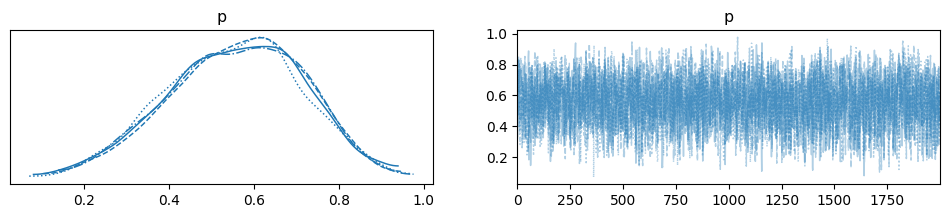

In [10]:
az.plot_trace(trace)

**収束評価基準**
- r_hat(収束基準) < 1.01
- ess_bulk(有効サンプルサイズ) > 1000
- traceが安定
- divergent(NUTS特有) = 0

# ガンマ分布・ポアソン分布
$$
X|\lambda \sim \text{Poisson} (\lambda)\ , \ \lambda \sim \text{Ga}(\alpha,\beta)
$$
$\lambda$の事後分布
$$
\lambda|\vec{X}=\vec{x} \sim \text{Poisson}\left(\sum_i x_i + \alpha , n + \beta\right)
$$

In [ ]:
# 観測データ（カウント）
x_data = np.array([3, 2, 4, 3, 5])  # 合計17, n=5

# 事前分布パラメータ
alpha_prior = 2.0
beta_prior = 1.0  # rate

with pm.Model() as gamma_poisson_model:
    # 事前分布
    lam = pm.Gamma("lam", alpha=alpha_prior, beta=beta_prior)

    # 尤度
    x_obs = pm.Poisson("x_obs", mu=lam, observed=x_data)

    # MCMC
    trace = pm.sample(
        draws=2000, tune=1000, chains=4, target_accept=0.9, return_inferencedata=True
    )

# 結果表示
az.summary(trace, var_names=["lam"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lam]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 19 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lam,3.198,0.722,1.867,4.51,0.013,0.009,2849.0,3632.0,1.0


array([[<Axes: title={'center': 'lam'}>, <Axes: title={'center': 'lam'}>]],
      dtype=object)

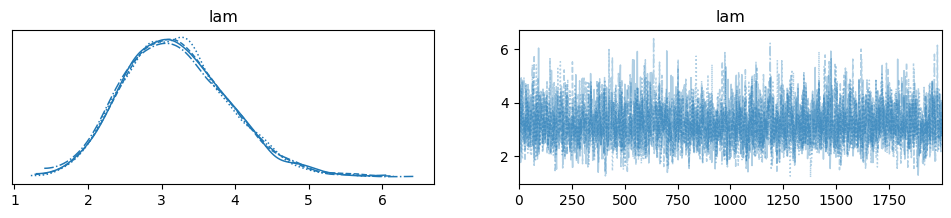

In [12]:
az.plot_trace(trace)

## データ準備

In [13]:
import sys
from pathlib import Path

# projectルートを追加
sys.path.append(str(PROJECT_DIR))

In [14]:
# make dataframe
from src.data_loader import load_csv_with_datetime_index
from src.preprocessing import normalize_default_counts

df = load_csv_with_datetime_index(
    (RAW_DATA_DIR / "default_counts/M.csv"),
    date_col="Year",
    date_format="%Y",
)

df = normalize_default_counts(df, scale=3000)
df.head()

=== CSV loaded ===
shape: (99, 7)
columns: ['Year', 'SG', 'D_SG', 'IG', 'D_IG', 'ALL', 'D_ALL']
=== DatetimeIndex set ===
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
DatetimeIndex(['1920-01-01', '1921-01-01', '1922-01-01', '1923-01-01',
               '1924-01-01'],
              dtype='datetime64[ns]', name='Year', freq=None)
[normalize_default_counts] created 'SG_norm' from 'D_SG' / 'SG' * 3000
[normalize_default_counts] created 'IG_norm' from 'D_IG' / 'IG' * 3000
[normalize_default_counts] created 'ALL_norm' from 'D_ALL' / 'ALL' * 3000


,SG,D_SG,IG,D_IG,ALL,D_ALL,SG_norm,IG_norm,ALL_norm
Year,,,,,,,,,
1920-01-01,831,25,1843,8,2674,33,90.252708,13.022246,37.023186
1921-01-01,1163,25,1833,7,2996,32,64.488392,11.456628,32.042724
1922-01-01,1305,23,1972,10,3277,33,52.873563,15.212982,30.210558
1923-01-01,1290,22,2068,5,3358,27,51.162791,7.253385,24.121501
1924-01-01,1297,37,2175,3,3472,40,85.582113,4.137931,34.562212


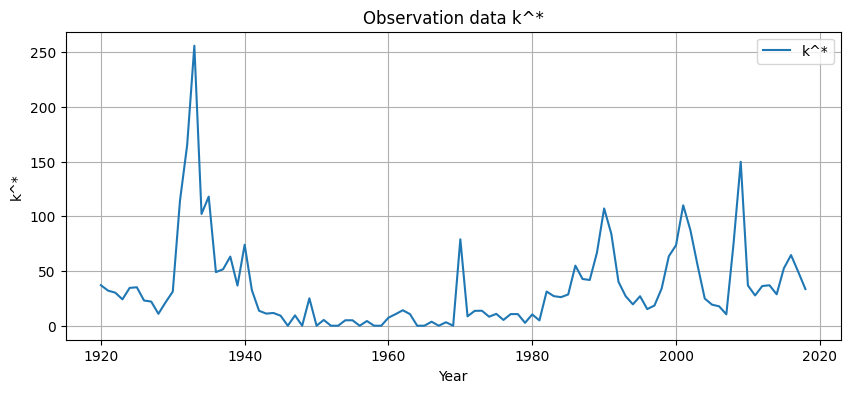

In [15]:
plt.figure(figsize=(10, 4))

plt.plot(df["ALL_norm"].index, df["ALL_norm"], label="k^*")
plt.title("Observation data k^*")
plt.xlabel("Year")
plt.ylabel("k^*")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
from src.data_loader import load_init_params

params = load_init_params()
params["scalar"]

{'lambda0_init': 15.371267399638784,
 'alpha_init': 1.6083656201283254,
 'theta_init': 0.8712653894606734,
 'gamma_init': 0.5537673935814657,
 'lambda0_se': 0.4784335726034531,
 'alpha_se': 0.0310453613292965,
 'theta_se': 0.00845159091048,
 'gamma_se': 0.0417128534516412,
 'lambda0_var': 0.2288986833941036,
 'alpha_var': 0.0009638144600665,
 'theta_var': 7.142938891810867e-05,
 'gamma_var': 0.001739962143078}

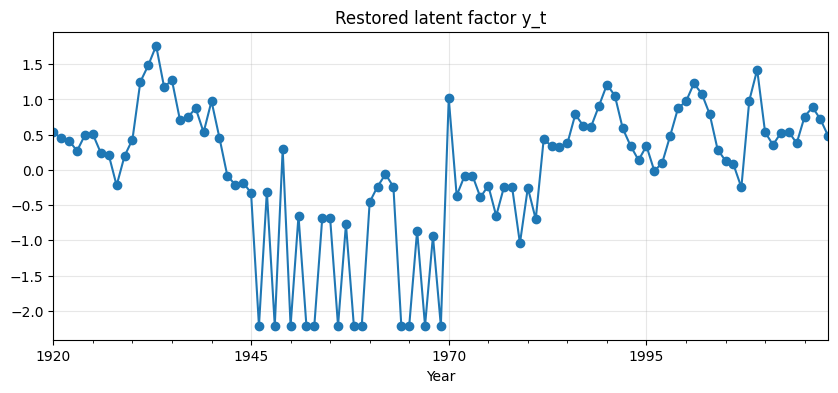

In [ ]:
y_init = pd.Series(params["y_init"], index=df.index, name="y_t")

y_init.plot(figsize=(10, 4), marker="o")
plt.title("Restored latent factor y_t")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
lambda0_init = params["scalar"]["lambda0_init"]
alpha_init = params["scalar"]["alpha_init"]
theta_init = params["scalar"]["theta_init"]
gamma_init = params["scalar"]["gamma_init"]

lambda0_se = params["scalar"]["lambda0_se"]
alpha_se = params["scalar"]["alpha_se"]
theta_se = params["scalar"]["theta_se"]
gamma_se = params["scalar"]["gamma_se"]

## ポアソン分布・正規分布($y_t$固定) ← GLM
$\eta_0 = \log{\lambda_0}$として
$$
X_t|(\lambda_0 , \alpha) , \vec{y}\sim   \text{Poisson}\left(\exp{(\eta_0 + \alpha y_t)}\right)
\ ,\ \eta_0 \sim \mathcal{N}(\mu_{\eta_0} , \sigma^2_{\eta_0})
\ ,\ \alpha \sim \mathcal{N^+}(\mu_{\alpha} , \sigma^2_{\alpha})
$$

ここでリンク関数（強度関数）を
$$
\lambda_t = \exp{(\eta_0 + \alpha y_t)}
$$

と置いた。

以下、
$\lambda_0 , \alpha $の事後分布$p(\lambda_0 , \alpha | \vec{k} , \vec{y})$は$\text{MCMC}$でシミュレーション

つまり
$$
p(\lambda_0 , \alpha | \vec{k} , \vec{y}) \propto p(\vec{k} | \eta_0 , \alpha , \vec{y}) p(\eta_0) p(\alpha)
$$

をMCMCを用いてシミュレーションする

In [ ]:
# =========================
# 1. データ準備
# =========================
k_data = df["ALL_norm"].to_numpy(dtype=float)
k_obs = np.rint(k_data).astype("int64")  # Poisson用に整数化

y_fixed = y_init.to_numpy(dtype=float)

T = len(k_obs)

# 初期値・事前分布の中心
eta0_init = float(np.log(lambda0_init))
alpha_init = float(alpha_init)

# 事前分布の幅
sigma_eta0 = float(lambda0_se / lambda0_init)
sigma_alpha = float(alpha_se)

c = 10.0

In [ ]:
# =========================
# 2. PyMCモデル
# =========================
with pm.Model() as glm_poisson_model:
    # priors
    eta0 = pm.Normal("eta0", mu=eta0_init, sigma=c * sigma_eta0)

    lambda0 = pm.Deterministic("lambda0", pm.math.exp(eta0))

    alpha = pm.TruncatedNormal("alpha", mu=alpha_init, sigma=c * sigma_alpha, lower=0.0)

    # linear predictor
    log_mu = eta0 + alpha * y_fixed

    # Poisson mean
    mu = pm.Deterministic("mu", pm.math.exp(log_mu))

    # likelihood
    x = pm.Poisson("x", mu=mu, observed=k_obs)

    # MCMC
    trace_glm = pm.sample(
        draws=500,
        tune=500,
        chains=4,
        cores=4,
        target_accept=0.9,
        random_seed=42,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True},
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [eta0, alpha]


Output()

Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 16 seconds.


In [ ]:
# =========================
# 3. 推定結果のサマリー
# =========================
print(eta0_init)
print(alpha_init)

summary = az.summary(trace_glm, var_names=["eta0", "lambda0", "alpha"], round_to=4)
summary

2.7325000134637905
1.6083656201283254


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
eta0,2.7342,0.0297,2.6798,2.7925,0.0013,0.0009,532.4813,597.3646,1.0083
lambda0,15.4042,0.4577,14.5820,16.3216,0.0198,0.0142,532.4813,597.3646,1.0083
alpha,1.6071,0.0291,1.5527,1.6634,0.0012,0.0010,552.3760,657.5031,1.0082


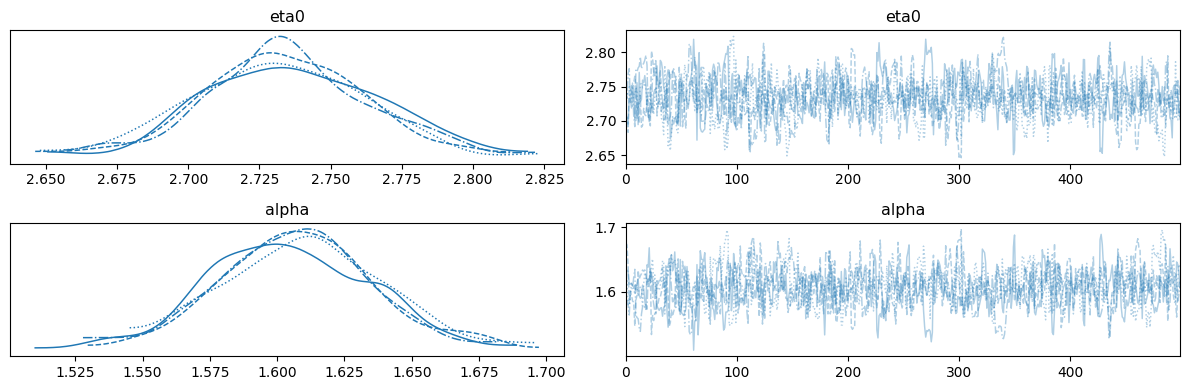

In [22]:
az.plot_trace(trace_glm, var_names=["eta0", "alpha"])
plt.tight_layout()
plt.show()

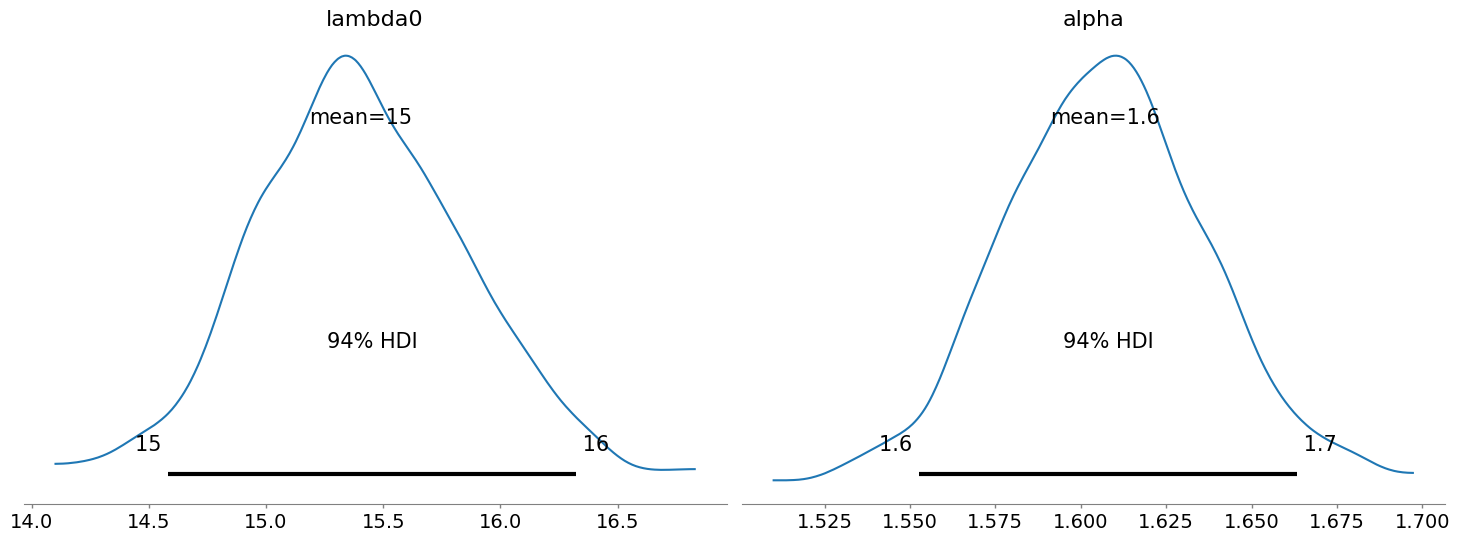

In [ ]:
# 事後分布
az.plot_posterior(trace_glm, var_names=["lambda0", "alpha"])
plt.tight_layout()
plt.show()

In [24]:
# =========================
# 4. WAIC
# =========================
waic_glm = az.waic(trace_glm)
print(waic_glm)

Computed from 2000 posterior samples and 99 observations log-likelihood matrix.

          Estimate       SE
elpd_waic  -227.64     8.28
p_waic        0.14        -


### (重要)LFO
$$
\text{LFO} = \sum_{t=t_0}^{T-1} 
\log\left( \int d\theta \ p(x_{t+1} | \theta) p(\theta | \vec{x})  \right) \simeq \sum^{T-1}_{t=t_0}\left(\frac{1}{S} \sum^S_{s=1} p(x_{t+1} | \theta^{(s)})\right)
$$

```python
one_step_log_pred_density
```
$$
\log\left( \int d\theta \ p(x_{t+1} | \theta) p(\theta | \vec{x})  \right)
$$

In [ ]:
# =========================
# 5. LFO
# =========================
import numpy as np
import pymc as pm
from scipy.special import gammaln, logsumexp


def fit_glm_mcmc(
    k_train,
    y_train,
    eta0_init,
    alpha_init,
    sigma_eta0=0.5,
    sigma_alpha=0.5,
    draws=1000,
    tune=1000,
    chains=2,
    cores=2,
    random_seed=42,
):
    with pm.Model() as model:
        eta0 = pm.Normal("eta0", mu=eta0_init, sigma=sigma_eta0)
        alpha = pm.TruncatedNormal("alpha", mu=alpha_init, sigma=sigma_alpha, lower=0.0)

        mu = pm.math.exp(eta0 + alpha * y_train)
        x = pm.Poisson("x", mu=mu, observed=k_train)

        idata = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            cores=cores,
            target_accept=0.9,
            random_seed=random_seed,
            return_inferencedata=True,
        )
    return idata

In [26]:
def one_step_log_pred_density(idata, k_next, y_next):
    eta0_s = idata.posterior["eta0"].values.reshape(-1)
    alpha_s = idata.posterior["alpha"].values.reshape(-1)

    mu_next = np.exp(eta0_s + alpha_s * y_next)

    # 各 posterior sample ごとの log p(k_next | theta_s)
    logp_s = k_next * np.log(mu_next) - mu_next - gammaln(k_next + 1)

    # posterior predictive density の対数:
    # log( mean_s p(k_next | theta_s) )
    return logsumexp(logp_s) - np.log(len(logp_s))

In [ ]:
t0 = 30  # 最初の学習長。例
lfo_scores = []

for t in range(t0, len(k_obs) - 1):
    k_train = k_obs[:t]
    y_train = y_fixed[:t]

    k_next = k_obs[t]
    y_next = y_fixed[t]

    idata_t = fit_glm_mcmc(
        k_train=k_train,
        y_train=y_train,
        eta0_init=eta0_init,
        alpha_init=alpha_init,
        sigma_eta0=sigma_eta0,
        sigma_alpha=sigma_alpha,
        draws=1000,
        tune=1000,
        chains=2,
        cores=2,
        random_seed=42,
    )

    lpd_t = one_step_log_pred_density(idata_t, k_next, y_next)
    lfo_scores.append(lpd_t)

lfo_total = np.sum(lfo_scores)
print("LFO total =", lfo_total)
print("n_folds   =", len(lfo_scores))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha]


...

Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


LFO total = -147.8766799274491
n_folds   = 68


In [28]:
print("LFO total =", lfo_total)
print("n_folds   =", len(lfo_scores))
print("LFO mean  =", lfo_total / len(lfo_scores))

LFO total = -147.8766799274491
n_folds   = 68
LFO mean  = -2.1746570577566042
